# Libraries

In [101]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from tqdm import tqdm
import os
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc, f1_score, matthews_corrcoef, average_precision_score
import pickle
import re
from datetime import datetime
import warnings
from sklearn.utils import resample

In [102]:
import gc
gc.collect()

32820

# Import Predictions and Targets

In [46]:
def prediction_import():

    '''Import predictions from all models and join them as one dataframe.'''

    # import predictions
    SAVE_DIR = 'Models'
    # pna_gfp_epoch_10 = pd.read_csv(f'{SAVE_DIR}/PNA_gfp/Predictions/predictions_all_pna_gfp_21_05_26.csv')
    # # pna_gfp_epoch_10.rename(columns={'score' : 'score_pna_gfp_epoch_10'}, inplace=True)
    # print('pna_gfp_epoch_10 shape: ', pna_gfp_epoch_10.shape)


    ############### PNA MODELS ###############

    pna_gfp_epoch_20 = pd.read_csv(f'{SAVE_DIR}/PNA_gfp/Predictions/predictions_all_pna_gfp_epochs_20_22_05_26.csv')
    print('pna_gfp_epoch_20 shape: ', pna_gfp_epoch_20.shape)

    pna_gfp_enh_epoch_20 = pd.read_csv(f'{SAVE_DIR}/PNA_gfp_enh/Predictions/predictions_all_pna_enh_gfp_epochs_20_22_05_26.csv')
    print('pna_gfp_enh_epoch_20 shape: ', pna_gfp_enh_epoch_20.shape)

    # pna_baseline = pd.read_csv(f'{SAVE_DIR}/PNA/Predictions/predictions_all_pna_11_05_26.csv')
    pna_baseline = pd.read_csv(f'{SAVE_DIR}/PNA/Predictions/predictions_all_pna_25_05_26.csv')
    print('pna_baseline shape: ', pna_baseline.shape)

    pna_rwpe = pd.read_csv(f'{SAVE_DIR}/PNA_rwpe/Predictions/predictions_all_pna_rwpe_24_05_26.csv')
    print('pna_rwpe shape: ', pna_rwpe.shape)

    pna_gfp_rwpe = pd.read_csv(f'{SAVE_DIR}/PNA_gfp_rwpe/Predictions/all_pna_gfp_rwpe_epochs_20_25_05_26.csv')
    print('pna_gfp_rwpe shape: ', pna_gfp_rwpe.shape)



    ################# GINe MODELS ###############

    # gine_gfp_epoch_10 = pd.read_csv(f'{SAVE_DIR}/GINe_gfp/Predictions/gine_predictions_all_gfp_21_05_26.csv')
    # # gine_gfp_epoch_10.rename(columns={'score' : 'score_gine_gfp_epoch_10'}, inplace=True)
    # print('gine_gfp_epoch_10 shape: ', gine_gfp_epoch_10.shape)

    gine_gfp_epoch_20 = pd.read_csv(f'{SAVE_DIR}/GINe_gfp/Predictions/gine_predictions_all_gfp_epocs_20_21_05_26.csv')
    print('gine_gfp_epoch_20: ', gine_gfp_epoch_20.shape)

    gine_baseline = pd.read_csv(f'{SAVE_DIR}/GINe_baseline/Predictions/predictions_all_11_05_26.csv')
    gine_baseline.rename(columns={'score' : 'score_gine_baseline'}, inplace=True)
    gine_baseline.drop(columns=['pred_thr05'], inplace=True)
    print('gine_baseline shape: ', gine_baseline.shape)

    gat_gfp_epoch_20 = pd.read_csv(f'{SAVE_DIR}/GAT_gfp/Predictions/predictions_all_gat_gfp_epochs_20_22_05_26.csv')
    print('gat_gfp_epoch_20 shape: ', gat_gfp_epoch_20.shape)

    gine_gfp_rwpe = pd.read_csv(f'{SAVE_DIR}/GINe_gfp_rwpe/Predictions/gine_predictions_all_gfp_rwpe_22_05_26.csv')
    print('gine_gfp_rwpe shape: ', gine_gfp_rwpe.shape)

    gine_rwpe = pd.read_csv(f'{SAVE_DIR}/GINe_rwpe/Predictions/gine_rwpe_predictions_all_25_05_26.csv')
    print('gine_rwpe shape: ', gine_rwpe.shape)

    gine_gfp_enh = pd.read_csv(f'{SAVE_DIR}/GINe_gfp_enh/Predictions/gine_gfp_enh_predictions_all_26_05_26.csv')
    print('gine_gfp_enh shape: ', gine_gfp_enh.shape)

    # gine_baseline_pcgnn = pd.read_csv(f'{SAVE_DIR}/GINe_baseline_pcgnn/Predictions/predictions_all_gine_pcgnn_24_05_26.csv')
    # print('gine_baseline_pcgnn shape: ', gine_baseline_pcgnn.shape)

    ########################## Gat Models ###############

    gat_baseline = pd.read_csv(f'{SAVE_DIR}/GAT_baseline/Predictions/predictions_all_gat_baseline_25_05_26.csv')
    print('gat_baseline shape: ', gat_baseline.shape)

    gat_gfp_epoch_20 = pd.read_csv(f'{SAVE_DIR}/GAT_gfp/Predictions/predictions_all_gat_gfp_epochs_20_22_05_26.csv')
    print('gat_gfp_epoch_20 shape: ', gat_gfp_epoch_20.shape)

    gat_rwpe = pd.read_csv(f'{SAVE_DIR}/GAT_rwpe/Predictions/predictions_all_gat_rwpe_25_05_26.csv')
    print('gat_rwpe shape: ', gat_rwpe.shape)

    gat_gfp_rwpe = pd.read_csv(f'{SAVE_DIR}/GAT_gfp_rwpe/Predictions/predictions_all_gat_gfp_rwpe_25_05_26.csv')
    print('gat_gfp_rwpe shape: ', gat_gfp_rwpe.shape)

    gat_gfp_enh = pd.read_csv(f'{SAVE_DIR}/GAT_gfp_enh/Predictions/gat_gfp_enh_predictions_all_26_05_26.csv')
    print('gat_gfp_enh shape: ', gat_gfp_enh.shape)




    ##################### XGBOOST MODEL ###############

    xgboost_gfp_rwpe = pd.read_csv(f'{SAVE_DIR}/XGBoost_GFP_RWPE/Predictions/predictions_all_25_05_26.csv')
    print('xgboost_gfp_rwpe shape: ', xgboost_gfp_rwpe.shape)

    
    ### Gine Models
    df = gine_baseline[['split', 'src_idx', 'dst_idx', 'timestamp', 'label', 'score_gine_baseline']].copy()
    df['score_gine_gfp'] = gine_gfp_epoch_20['score']
    df['score_gine_rwpe'] = gine_rwpe['score']
    df['score_gine_gfp_rwpe'] = gine_gfp_rwpe['score']
    df['score_gine_gfp_enh'] = gine_gfp_enh['score']



    ### Gat Models
    df['score_gat_baseline'] = gat_baseline['score']
    df['score_gat_gfp'] = gat_gfp_epoch_20['score']
    df['score_gat_rwpe'] = gat_rwpe['score']
    df['score_gat_gfp_rwpe'] = gat_gfp_rwpe['score']
    df['score_gat_gfp_enh'] = gat_gfp_enh['score']


    ### PNA Models
    df['score_pna_baseline'] = pna_baseline['score']
    df['score_pna_gfp'] = pna_gfp_epoch_20['score']
    df['score_pna_rwpe'] = pna_rwpe['score']
    df['score_pna_gfp_rwpe'] = pna_gfp_rwpe['score']
    df['score_pna_gfp_enh'] = pna_gfp_enh_epoch_20['score']



    #### XGBoost Model
    df['score_xgboost_gfp_rwpe'] = xgboost_gfp_rwpe['score']


    # df['score_pna_baseline'] = pna_baseline['score']
    # # df['score_gine_gfp_epoch_10'] = gine_gfp_epoch_10['score']
    # df['score_gine_gfp_epoch_20'] = gine_gfp_epoch_20['score']
    # # df['score_pna_gfp_epoch_10'] = pna_gfp_epoch_10['score']
    # df['score_pna_gfp_epoch_20'] = pna_gfp_epoch_20['score']
    # df['score_pna_gfp_enh_epoch_20'] = pna_gfp_enh_epoch_20['score']
    # df['score_gat_gfp_epoch_20'] = gat_gfp_epoch_20['score']
    # df['score_gine_gfp_rwpe'] = gine_gfp_rwpe['score']
    # # df['score_gine_baseline_pcgnn'] = gine_baseline_pcgnn['score']
    # df['score_pna_rwpe'] = pna_rwpe['score']
    # df['score_pna_gfp_rwpe'] = pna_gfp_rwpe['score']
    # df['score_xgboost_gfp_rwpe'] = xgboost_gfp_rwpe['score']
    
    return df

In [47]:
df = prediction_import()

pna_gfp_epoch_20 shape:  (6924049, 6)
pna_gfp_enh_epoch_20 shape:  (6924049, 6)
pna_baseline shape:  (6924049, 6)
pna_rwpe shape:  (6924049, 6)
pna_gfp_rwpe shape:  (6924049, 6)
gine_gfp_epoch_20:  (6924049, 6)
gine_baseline shape:  (6924049, 6)
gat_gfp_epoch_20 shape:  (6924049, 6)
gine_gfp_rwpe shape:  (6924049, 6)
gine_rwpe shape:  (6924049, 6)
gine_gfp_enh shape:  (6924049, 6)
gat_baseline shape:  (6924049, 6)
gat_gfp_epoch_20 shape:  (6924049, 6)
gat_rwpe shape:  (6924049, 6)
gat_gfp_rwpe shape:  (6924049, 6)
gat_gfp_enh shape:  (6924049, 6)
xgboost_gfp_rwpe shape:  (6924049, 3)


In [48]:
df.shape

(6924049, 21)

In [49]:
def evaluate_aml_model(train_true, train_score,
                       valid_true, valid_score,
                       test_true,  test_score,
                       use_default_threshold=False):   # ← new parameter

    train_true, train_score = np.array(train_true), np.array(train_score)
    valid_true, valid_score = np.array(valid_true), np.array(valid_score)
    test_true,  test_score  = np.array(test_true),  np.array(test_score)

    # ── 1. Find optimal thresholds on the TRAIN set ──────────────────────────

    if use_default_threshold:
        # Paper-style: fixed threshold, no optimisation
        best_thresh_f1  = 0.5
        best_thresh_mcc = 0.5
    else:
        # Optimise both thresholds on the validation set
        precision, recall, thresholds = precision_recall_curve(valid_true, valid_score)

        with np.errstate(divide='ignore', invalid='ignore'):
            f1_scores = 2 * (precision * recall) / (precision + recall)
        f1_scores = np.nan_to_num(f1_scores)
        best_thresh_f1 = thresholds[np.argmax(f1_scores[:-1])]

        P  = np.sum(valid_true == 1)
        N  = np.sum(valid_true == 0)
        TP = recall[:-1] * P
        FN = P - TP
        with np.errstate(divide='ignore', invalid='ignore'):
            FP = np.where(precision[:-1] > 0, (TP / precision[:-1]) - TP, 0)
        TN = N - FP
        mcc_num = (TP * TN) - (FP * FN)
        mcc_den = np.sqrt((TP + FP) * (TP + FN) * (TN + FP) * (TN + FN))
        with np.errstate(divide='ignore', invalid='ignore'):
            mcc_scores = np.divide(mcc_num, mcc_den, out=np.zeros_like(mcc_num), where=mcc_den != 0)
        best_thresh_mcc = thresholds[np.argmax(mcc_scores)]

     # ── 2. Helper to evaluate a specific split ───────────────────────────────
    def evaluate_split(y_true, y_score, split_name):
        roc_auc = roc_auc_score(y_true, y_score)
        
        pr, rec, _ = precision_recall_curve(y_true, y_score)
        pr_auc = auc(rec, pr)
        
        # Apply train-optimized thresholds
        pred_f1  = (y_score >= best_thresh_f1).astype(int)
        pred_mcc = (y_score >= best_thresh_mcc).astype(int)
        
        split_f1 = f1_score(y_true, pred_f1)
        split_mcc = matthews_corrcoef(y_true, pred_mcc)
        
        return {
            'Split': split_name,
            'ROC_AUC': round(roc_auc*100, 2),
            'PR_AUC': round(pr_auc*100, 2),
            'F1_Score': round(split_f1*100, 2),
            'MCC': round(split_mcc*100, 2),
            'Thresh_F1_Used': round(best_thresh_f1, 4),
            'Thresh_MCC_Used': round(best_thresh_mcc, 4)
        }

    # ── 3. Evaluate all splits ───────────────────────────────────────────────
    results = [
        evaluate_split(train_true, train_score, 'Train'),
        evaluate_split(valid_true, valid_score, 'Validation'),
        evaluate_split(test_true, test_score, 'Test')
    ]
    
    # ── 4. Return formatted DataFrame ────────────────────────────────────────
    df_results = pd.DataFrame(results)
    
    # Optional: reorder and round columns for better readability
    df_results = df_results.round(4)
    df_results.set_index('Split', inplace=True)
    
    return df_results




def compare_all_models(df, use_default_threshold=False):
    """
    Evaluate all models across splits and return a comparison DataFrame.
    
    Parameters
    ----------
    df                    : DataFrame with columns split, label, score_<model_name>, ...
    use_default_threshold : if True, use threshold=0.5 (paper style)
                           if False, optimise threshold on validation set (default)
    
    Returns
    -------
    results_df : DataFrame with columns [model, split, pr_auc, roc_auc, f1, mcc]
    """
    score_cols = [c for c in df.columns if c.startswith('score_')]

    train = df[df['split'] == 'train']
    val   = df[df['split'] == 'val']
    test  = df[df['split'] == 'test']

    rows = []
    for col in score_cols:
        model_name = col.replace('score_', '')
        result = evaluate_aml_model(
            train['label'], train[col],
            val['label'],   val[col],
            test['label'],  test[col],
            use_default_threshold=use_default_threshold,
        )
        result = result.reset_index()
        result.insert(0, 'model', model_name)
        rows.append(result)

    return pd.concat(rows, ignore_index=True)

In [50]:
# ── Usage ──────────────────────────────────────────────────────────────────
results_05 = compare_all_models(df, use_default_threshold=True)
results = compare_all_models(df, use_default_threshold=False)

In [51]:
results

,model,Split,ROC_AUC,PR_AUC,F1_Score,MCC,Thresh_F1_Used,Thresh_MCC_Used
0,gine_baseline,Train,96.59,2.60,7.10,11.05,0.5472,0.4336
1,gine_baseline,Validation,95.81,3.47,9.75,12.57,0.5472,0.4336
2,gine_baseline,Test,96.18,3.46,9.62,13.02,0.5472,0.4336
3,gine_gfp,Train,98.42,19.09,23.20,24.59,0.4686,0.6328
4,gine_gfp,Validation,97.14,17.78,22.91,26.03,0.4686,0.6328
5,gine_gfp,Test,97.17,18.56,23.88,27.02,0.4686,0.6328
6,gine_rwpe,Train,97.67,16.23,14.98,18.82,0.1991,0.1436
7,gine_rwpe,Validation,96.72,10.84,15.75,18.22,0.1991,0.1436
8,gine_rwpe,Test,96.68,15.17,16.11,18.18,0.1991,0.1436
9,gine_gfp_rwpe,Train,98.66,22.46,26.30,28.16,0.5279,0.8036


In [52]:
results_05

,model,Split,ROC_AUC,PR_AUC,F1_Score,MCC,Thresh_F1_Used,Thresh_MCC_Used
0,gine_baseline,Train,96.59,2.60,6.34,11.17,0.5,0.5
1,gine_baseline,Validation,95.81,3.47,8.45,11.27,0.5,0.5
2,gine_baseline,Test,96.18,3.46,9.05,13.28,0.5,0.5
3,gine_gfp,Train,98.42,19.09,23.21,23.22,0.5,0.5
4,gine_gfp,Validation,97.14,17.78,22.31,23.50,0.5,0.5
5,gine_gfp,Test,97.17,18.56,23.97,25.41,0.5,0.5
6,gine_rwpe,Train,97.67,16.23,21.24,23.81,0.5,0.5
7,gine_rwpe,Validation,96.72,10.84,10.55,16.86,0.5,0.5
8,gine_rwpe,Test,96.68,15.17,17.65,21.75,0.5,0.5
9,gine_gfp_rwpe,Train,98.66,22.46,25.72,25.74,0.5,0.5


In [ ]:
def plot_gnn_aml_results(df):
    """
    Generates professional grouped bar charts for PR_AUC, MCC, and F1_Score.
    Filters for Test set and compares Baseline, GFP, RWPE, GFP+RWPE, and GFP (Enhanced).
    Includes XGBoost as a non-graph baseline.
    """
    # 1. Filter for the Test split
    test_df = df[df['Split'] == 'Test'].copy()

    # 2. Helper function to cleanly extract architecture and feature set
    def parse_model_info(row):
        model_name = str(row['model']).lower()
        
        # Identify base architecture
        if 'gine' in model_name: base = 'GINE'
        elif 'gat' in model_name: base = 'GAT'
        elif 'pna' in model_name: base = 'PNA'
        elif 'xgboost' in model_name: base = 'XGBoost'
        else: base = 'Other'
        
        # Identify feature strategy
        if 'gfp_rwpe' in model_name: features = 'GFP + RWPE'
        elif 'gfp_enh' in model_name: features = 'GFP (Enhanced)' # Added split projection logic
        elif 'gfp' in model_name: features = 'GFP'
        elif 'rwpe' in model_name: features = 'RWPE'
        elif 'baseline' in model_name: features = 'Baseline'
        else: features = 'Other'
        
        return pd.Series([base, features])

    # Apply extraction and filter out unwanted models
    test_df[['Base_Model', 'Features']] = test_df.apply(parse_model_info, axis=1)
    
    # Fixed the XGBoost naming mismatch here
    test_df = test_df[
        (test_df['Base_Model'].isin(['GINE', 'GAT', 'PNA', 'XGBoost'])) & 
        (test_df['Features'].isin(['Baseline', 'GFP', 'RWPE', 'GFP + RWPE', 'GFP (Enhanced)']))
    ]

    # Define strict order for the x-axis and legend 
    model_order = ['GINE', 'GAT', 'PNA', 'XGBoost']
    feature_order = ['Baseline', 'GFP', 'RWPE', 'GFP + RWPE', 'GFP (Enhanced)']

    # 3. Setup visual theme
    sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
    
    metrics = {
        'PR_AUC': 'PR AUC Score',
        'MCC': 'Matthew Correlation Coefficient (MCC)',
        'F1_Score': 'F1 Score'
    }
    
    # 4. Generate the 3 separate plots
    for column, y_label in metrics.items():
        plt.figure(figsize=(10, 6))
        
        ax = sns.barplot(
            data=test_df, 
            x='Base_Model', 
            y=column, 
            hue='Features',
            hue_order=feature_order,
            order=model_order,
            palette='tab10' # High-contrast qualitative palette
        )
        
        # Thesis-level formatting
        plt.title(f'Test Set Performance: {y_label} by Architecture', pad=15, fontweight='bold')
        plt.xlabel('Base Model Architecture', fontweight='bold')
        plt.ylabel(y_label, fontweight='bold')
        
        # Move legend outside the plot
        plt.legend(title='Node Features', bbox_to_anchor=(1.05, 1), loc='upper left')
        
        # Add exact values on top of each bar for precision
        for p in ax.patches:
            height = p.get_height()
            if pd.notnull(height) and height > 0:
                ax.annotate(f'{height:.1f}', 
                            (p.get_x() + p.get_width() / 2., height),
                            ha='center', va='bottom', 
                            xytext=(0, 4), textcoords='offset points',
                            fontsize=9)
        
        # Adjust layout and render
        plt.tight_layout()
        plt.show()

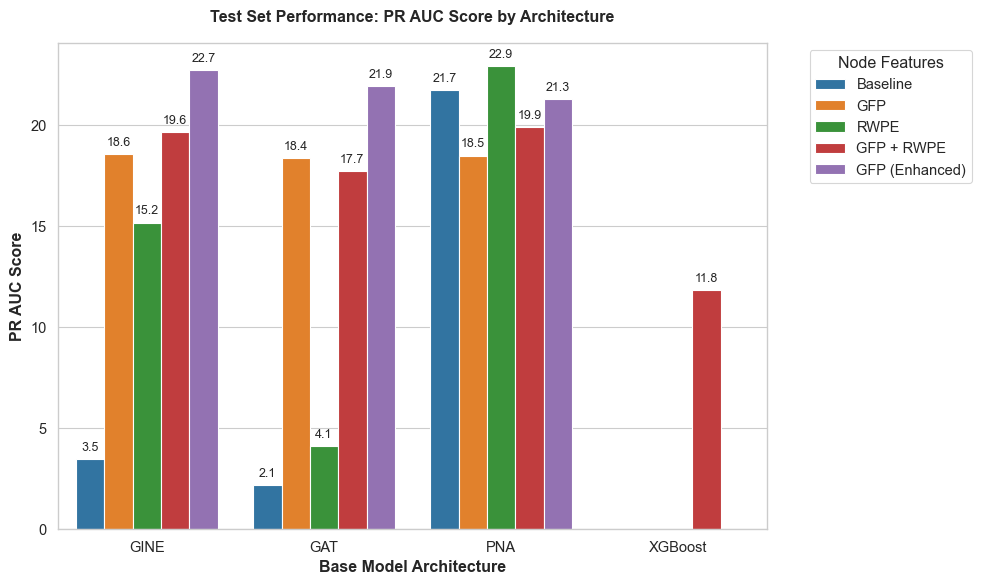

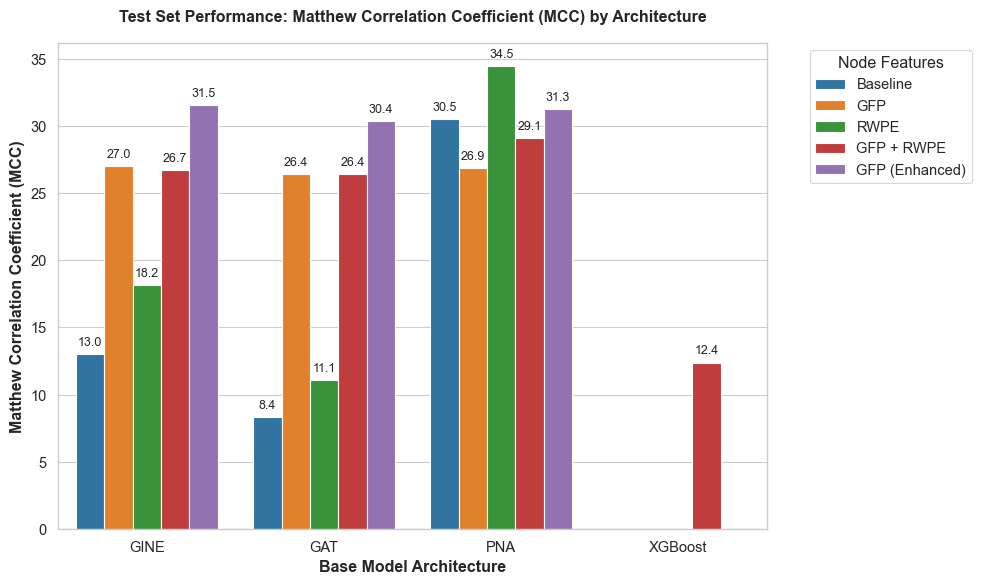

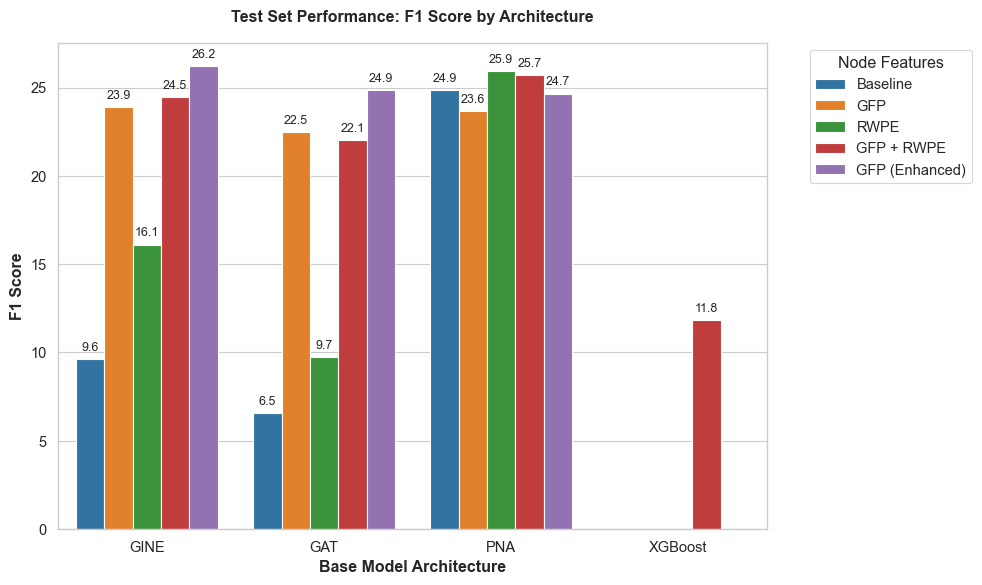

In [54]:
# To run it, simply pass your results dataframe:
plot_gnn_aml_results(results)

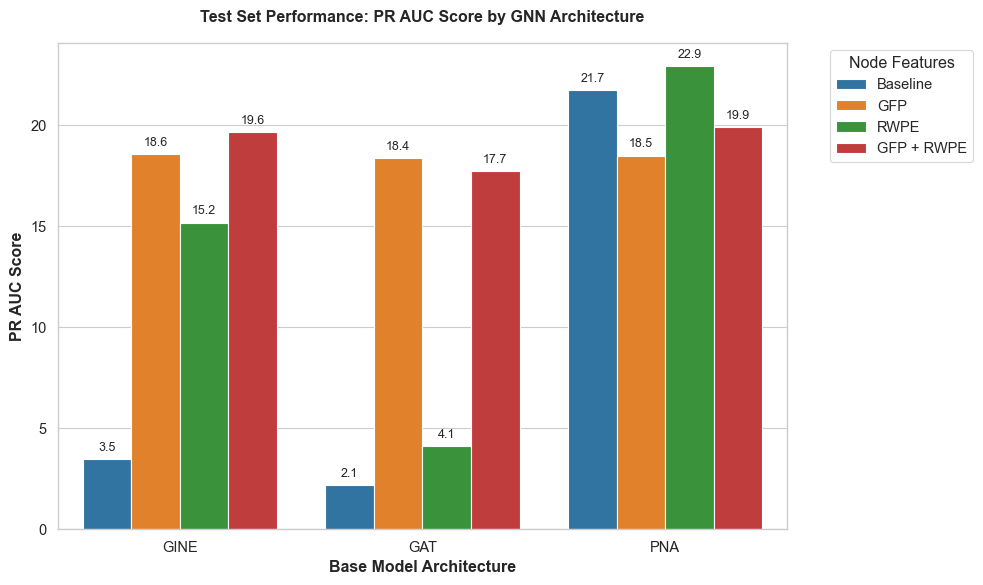

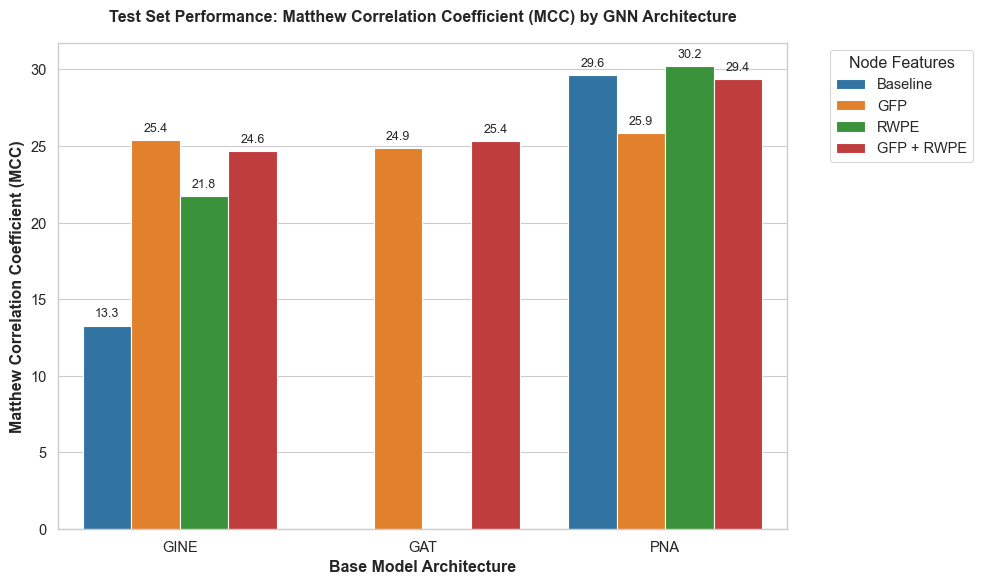

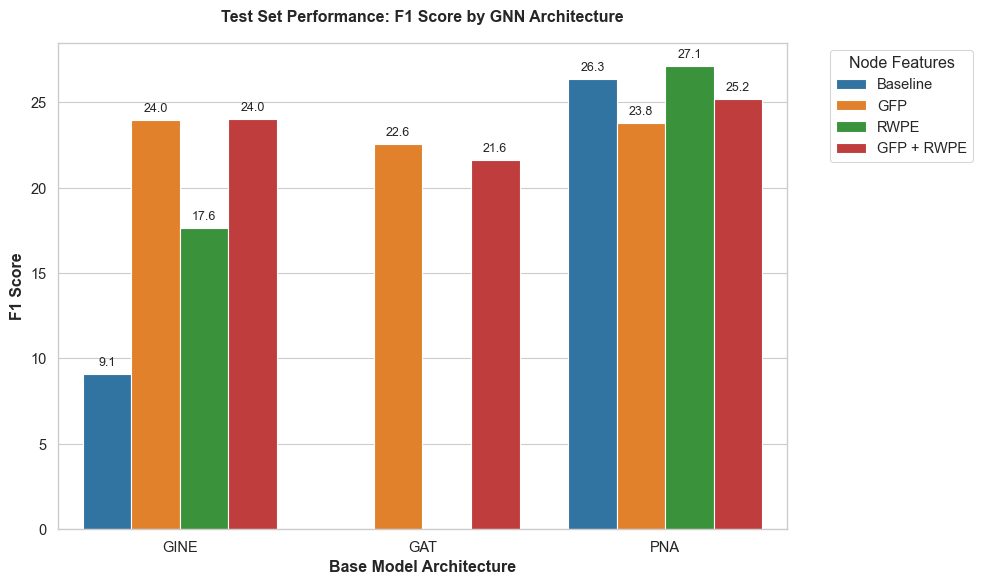

In [39]:
# To run it, simply pass your results dataframe:
plot_gnn_aml_results(results_05)

# Bootstrap Measurements

In [69]:
def evaluate_aml_model_stratified_bootstrapped(train_true, train_score,
                                               valid_true, valid_score,
                                               test_true,  test_score,
                                               use_default_threshold=False,
                                               n_iterations=100):
    
    train_true, train_score = np.array(train_true), np.array(train_score)
    valid_true, valid_score = np.array(valid_true), np.array(valid_score)
    test_true,  test_score  = np.array(test_true),  np.array(test_score)

    # ── 1. Find optimal thresholds on the validation set ────────────────────
    if use_default_threshold:
        best_thresh_f1  = 0.5
        best_thresh_mcc = 0.5
    else:
        precision, recall, thresholds = precision_recall_curve(valid_true, valid_score)
        with np.errstate(divide='ignore', invalid='ignore'):
            f1_scores = 2 * (precision * recall) / (precision + recall)
        f1_scores = np.nan_to_num(f1_scores)
        best_thresh_f1 = thresholds[np.argmax(f1_scores[:-1])]

        P  = np.sum(valid_true == 1)
        N  = np.sum(valid_true == 0)
        TP = recall[:-1] * P
        FN = P - TP
        with np.errstate(divide='ignore', invalid='ignore'):
            FP = np.where(precision[:-1] > 0, (TP / precision[:-1]) - TP, 0)
        TN = N - FP
        mcc_num = (TP * TN) - (FP * FN)
        mcc_den = np.sqrt((TP + FP) * (TP + FN) * (TN + FP) * (TN + FN))
        with np.errstate(divide='ignore', invalid='ignore'):
            mcc_scores = np.divide(mcc_num, mcc_den, out=np.zeros_like(mcc_num), where=mcc_den != 0)
        best_thresh_mcc = thresholds[np.argmax(mcc_scores)]

    # Get indices for both classes in the test set
    pos_indices = np.where(test_true == 1)[0]
    neg_indices = np.where(test_true == 0)[0]

    # ── 2. Stratified Bootstrap Loop ─────────────────────────────────────────
    bootstrapped_results = []
    
    for i in tqdm(range(n_iterations), desc='Bootstrapping'):
        # Resample positive and negative classes separately to maintain exact class sizes
        boot_pos_idx = resample(pos_indices, replace=True, n_samples=len(pos_indices), random_state=i)
        boot_neg_idx = resample(neg_indices, replace=True, n_samples=len(neg_indices), random_state=i + 1000)
        
        # Combine them back into a single test sample
        idx = np.concatenate([boot_pos_idx, boot_neg_idx])
        
        y_t_boot = test_true[idx]
        y_s_boot = test_score[idx]
        
        # Compute metrics
        roc_auc = roc_auc_score(y_t_boot, y_s_boot)
        pr, rec, _ = precision_recall_curve(y_t_boot, y_s_boot)
        pr_auc = auc(rec, pr)
        
        # Apply frozen thresholds
        pred_f1  = (y_s_boot >= best_thresh_f1).astype(int)
        pred_mcc = (y_s_boot >= best_thresh_mcc).astype(int)
        
        split_f1 = f1_score(y_t_boot, pred_f1)
        split_mcc = matthews_corrcoef(y_t_boot, pred_mcc)
        
        bootstrapped_results.append({
            'Iteration': i,
            'ROC_AUC': roc_auc * 100,
            'PR_AUC': pr_auc * 100,
            'F1_Score': split_f1 * 100,
            'MCC': split_mcc * 100
        })

    return pd.DataFrame(bootstrapped_results)

def compare_all_models_bootstrapped(df, use_default_threshold=False, n_iterations=100):
    score_cols = [c for c in df.columns if c.startswith('score_')]
    train = df[df['split'] == 'train']
    val   = df[df['split'] == 'val']
    test  = df[df['split'] == 'test']

    rows = []
    for col in tqdm(score_cols):
        model_name = col.replace('score_', '')
        
        # Returns a dataframe of 100 iterations for the test set
        result_df = evaluate_aml_model_stratified_bootstrapped(
            train['label'], train[col],
            val['label'],   val[col],
            test['label'],  test[col],
            use_default_threshold=use_default_threshold,
            n_iterations=n_iterations
        )
        
        result_df.insert(0, 'model', model_name)
        rows.append(result_df)

    return pd.concat(rows, ignore_index=True)

In [70]:
boot_results = compare_all_models_bootstrapped(df, use_default_threshold=False, n_iterations=100)

100%|██████████| 16/16 [28:21<00:00, 106.31s/it]


In [77]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

def plot_gnn_aml_bootstrapped(df):
    """
    Generates grouped bar charts for PR_AUC, MCC, and F1_Score using bootstrapped data.
    Automatically calculates the mean and draws 95% confidence intervals (error bars).
    """
    # 1. Helper function to extract architecture and feature set
    def parse_model_info(row):
        model_name = str(row['model']).lower()
        if 'gine' in model_name: base = 'GINE'
        elif 'gat' in model_name: base = 'GAT'
        elif 'pna' in model_name: base = 'PNA'
        elif 'xgboost' in model_name: base = 'XGBoost'
        else: base = 'Other'
        
        if 'gfp_rwpe' in model_name: features = 'GFP + RWPE'
        elif 'gfp_enh' in model_name: features = 'GFP (Enhanced)'
        elif 'gfp' in model_name: features = 'GFP'
        elif 'rwpe' in model_name: features = 'RWPE'
        elif 'baseline' in model_name: features = 'Baseline'
        else: features = 'Other'
        
        return pd.Series([base, features])

    # Apply extraction and filter
    plot_df = df.copy()
    plot_df[['Base_Model', 'Features']] = plot_df.apply(parse_model_info, axis=1)
    plot_df = plot_df[
        (plot_df['Base_Model'].isin(['GINE', 'GAT', 'PNA', 'XGBoost'])) & 
        (plot_df['Features'].isin(['Baseline', 'GFP', 'RWPE', 'GFP + RWPE', 'GFP (Enhanced)']))
    ]

    model_order = ['GINE', 'GAT', 'PNA', 'XGBoost']
    feature_order = ['Baseline', 'GFP', 'RWPE', 'GFP + RWPE', 'GFP (Enhanced)']

    # 2. Visual theme setup (Using high-contrast 'tab10' for discrete categories)
    sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
    
    # ADDED 'PR_AUC' back to the metrics loop dictionary
    metrics = {
        'PR_AUC': 'PR AUC Score',
        'F1_Score': 'F1 Score',
        'MCC': 'Matthew Correlation Coefficient (MCC)'
    }
    
    # 3. Generate the 3 separate plots
    for column, y_label in metrics.items():
        plt.figure(figsize=(11, 6))
        
        # errorbar=('ci', 95) aggregates the 100 rows per group, plotting the mean
        # as the bar height and adding 95% confidence interval whiskers
        ax = sns.barplot(
            data=plot_df, 
            x='Base_Model', 
            y=column, 
            hue='Features',
            hue_order=feature_order,
            order=model_order,
            palette='tab10',
            errorbar=('ci', 95), 
            capsize=0.04, 
            err_kws={'linewidth': 1.5}
        )
        
        plt.title(f'Bootstrapped Test Performance: {y_label} (95% CI)', pad=15, fontweight='bold')
        plt.xlabel('Base Model Architecture', fontweight='bold')
        plt.ylabel(y_label, fontweight='bold')
        plt.legend(title='Node Features', bbox_to_anchor=(1.02, 1), loc='upper left')
        
        # Annotate the mean value over the bars
        for p in ax.patches:
            height = p.get_height()
            if pd.notnull(height) and height > 0:
                # Dynamic precision check: If values are raw ratios (<= 1.0), use 2 decimal places. 
                # If they are percentages (> 1.0), use 1 decimal place.
                label_format = f'{height:.2f}' if height <= 1.0 else f'{height:.1f}'
                
                ax.annotate(label_format, 
                            (p.get_x() + p.get_width() / 2., height),
                            ha='center', va='bottom', 
                            xytext=(0, 14), textcoords='offset points', # Clearance for the CI whiskers
                            fontsize=9)
        
        plt.tight_layout()
        plt.show()

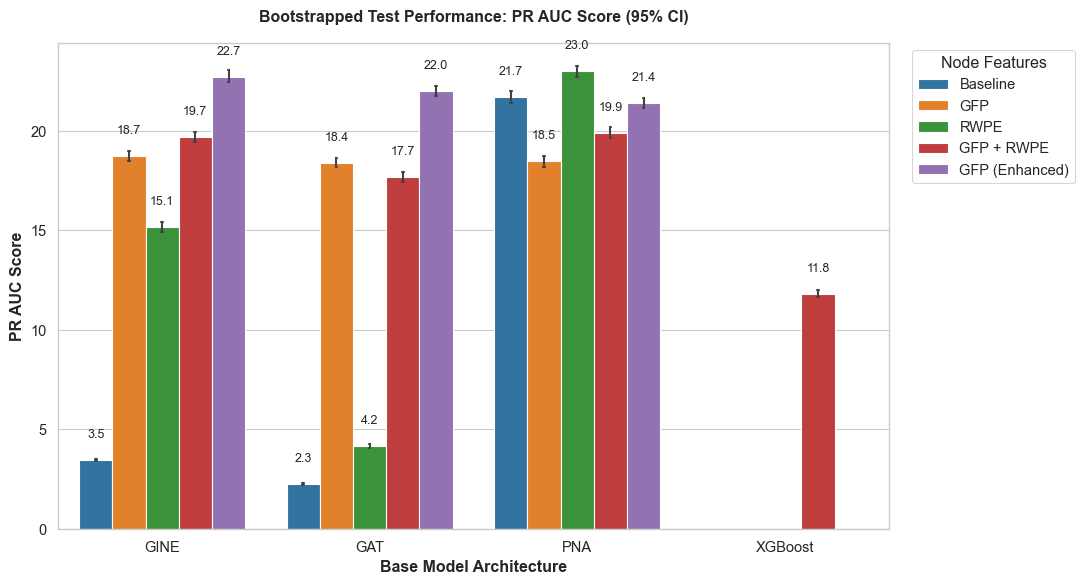

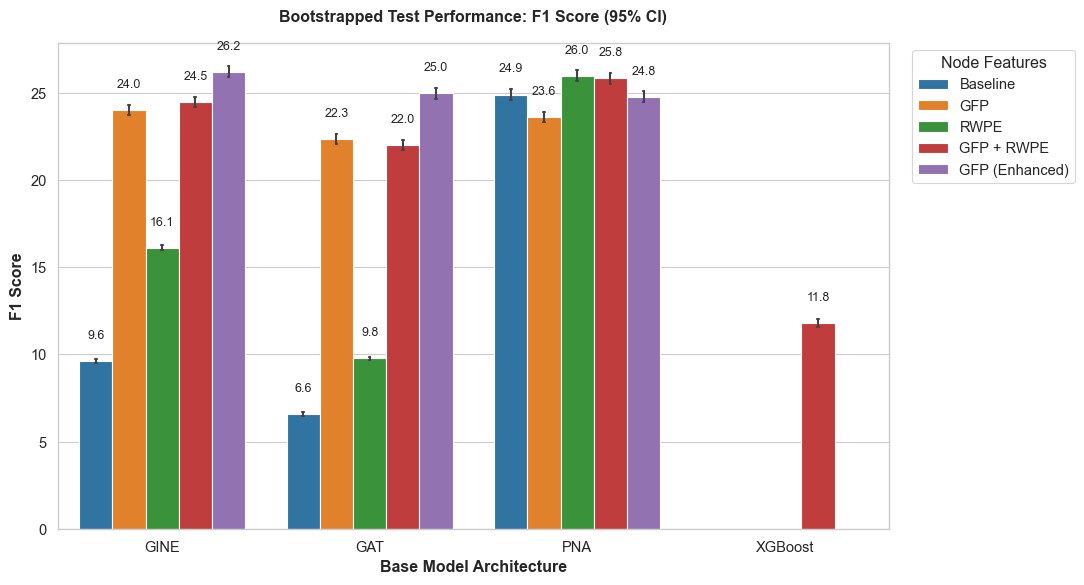

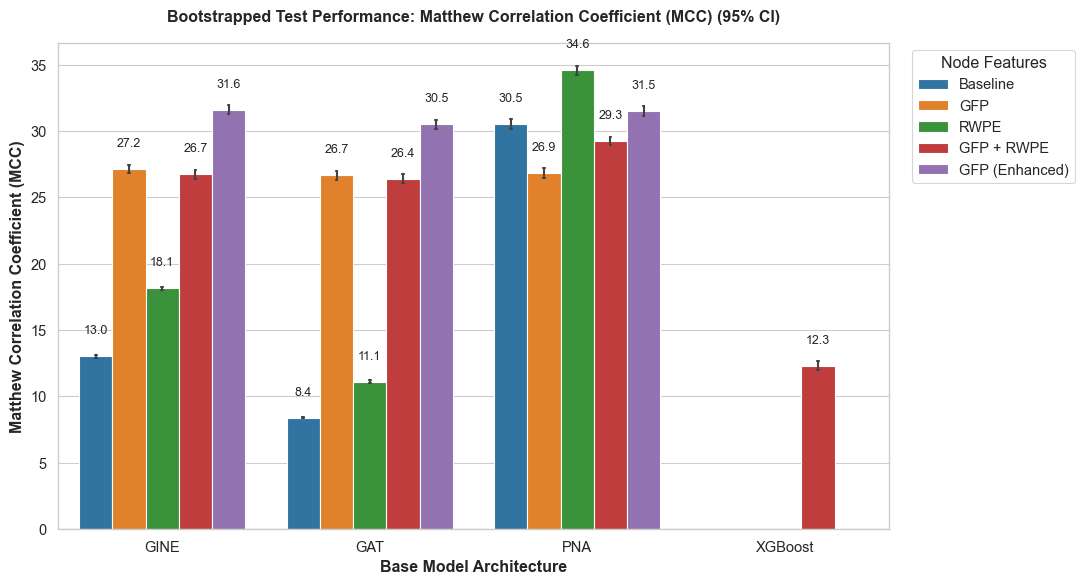

In [79]:
plot_gnn_aml_bootstrapped(boot_results)

# Precision@K, Recall@K

In [82]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker

def evaluate_top_k_all_models(test_df, k_percentages=[1, 5, 10, 15, 20, 25]):
    """
    Calculates and plots Precision@K and Recall@K as grouped bar charts 
    for each Base Architecture separately.
    """
    y_true = test_df['label'].values
    total_samples = len(y_true)
    total_positives = int(np.sum(y_true))
    
    score_cols = [c for c in test_df.columns if c.startswith('score_')]
    
    # 1. Helper to extract Architecture and Feature from column names
    def parse_model_info(col_name):
        model_name = col_name.replace('score_', '').lower()
        if 'gine' in model_name: base = 'GINE'
        elif 'gat' in model_name: base = 'GAT'
        elif 'pna' in model_name: base = 'PNA'
        elif 'xgboost' in model_name: base = 'XGBoost'
        else: base = 'Other'
        
        if 'gfp_rwpe' in model_name: features = 'GFP + RWPE'
        elif 'gfp_enh' in model_name: features = 'GFP (Enhanced)'
        elif 'gfp' in model_name: features = 'GFP'
        elif 'rwpe' in model_name: features = 'RWPE'
        elif 'baseline' in model_name: features = 'Baseline'
        else: features = 'Other'
        
        return base, features

    # 2. Calculate Top-K metrics for all models
    rows = []
    for col in score_cols:
        base, features = parse_model_info(col)
        if base == 'Other' or features == 'Other':
            continue
            
        scores = test_df[col].values
        sorted_idx = np.argsort(scores)[::-1]
        sorted_labels = y_true[sorted_idx]
        
        for k in k_percentages:
            n_top = max(1, int(total_samples * k / 100.0))
            tp = np.sum(sorted_labels[:n_top])
            
            rows.append({
                'Base_Model': base,
                'Features': features,
                'K%': k,
                'Precision': (tp / n_top) * 100, 
                'Recall': (tp / total_positives) * 100
            })
            
    df_metrics = pd.DataFrame(rows)
    
    # 3. Plotting Setup
    sns.set_theme(style="whitegrid", context="paper", font_scale=1.1)
    feature_order = ['Baseline', 'GFP', 'RWPE', 'GFP + RWPE', 'GFP (Enhanced)']
    base_models = ['GINE', 'GAT', 'PNA', 'XGBoost']
    
    # 4. Generate a separate figure for each Base Architecture
    for base in base_models:
        subset = df_metrics[df_metrics['Base_Model'] == base]
        if subset.empty:
            continue
            
        fig, axes = plt.subplots(1, 2, figsize=(15, 6))
        fig.suptitle(f'Top-K% Performance: {base} Architecture', fontsize=16, fontweight='bold', y=1.05)
        
        # Plot Precision
        ax_prec = sns.barplot(data=subset, x='K%', y='Precision', hue='Features', 
                              hue_order=feature_order, palette='tab10', ax=axes[0])
        axes[0].set_title('Precision @ K%', fontsize=13, fontweight='bold')
        axes[0].set_ylabel('Precision (%)', fontsize=11, fontweight='bold')
        axes[0].set_xlabel('Top K% of Transactions Reviewed', fontsize=11, fontweight='bold')
        axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
        
        # Plot Recall
        ax_rec = sns.barplot(data=subset, x='K%', y='Recall', hue='Features', 
                             hue_order=feature_order, palette='tab10', ax=axes[1])
        axes[1].set_title('Recall @ K%', fontsize=13, fontweight='bold')
        axes[1].set_ylabel('Recall (%)', fontsize=11, fontweight='bold')
        axes[1].set_xlabel('Top K% of Transactions Reviewed', fontsize=11, fontweight='bold')
        axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
        
        # --- Single Legend Logic ---
        # Remove the legend from the first subplot (Precision)
        if axes[0].get_legend() is not None:
            axes[0].get_legend().remove()
            
        # Configure the single legend on the second subplot (Recall) and move it outside
        axes[1].legend(title='Node Features', fontsize=9, title_fontsize=10, 
                       bbox_to_anchor=(1.05, 1), loc='upper left')

        # Add value annotations on top of the bars
        for ax in axes:
            for p in ax.patches:
                height = p.get_height()
                if pd.notnull(height) and height > 0:
                    ax.annotate(f'{height:.1f}', 
                                (p.get_x() + p.get_width() / 2., height),
                                ha='center', va='bottom', 
                                xytext=(0, 3), textcoords='offset points',
                                fontsize=8, rotation=90) 

        plt.tight_layout()
        plt.show()

    return df_metrics

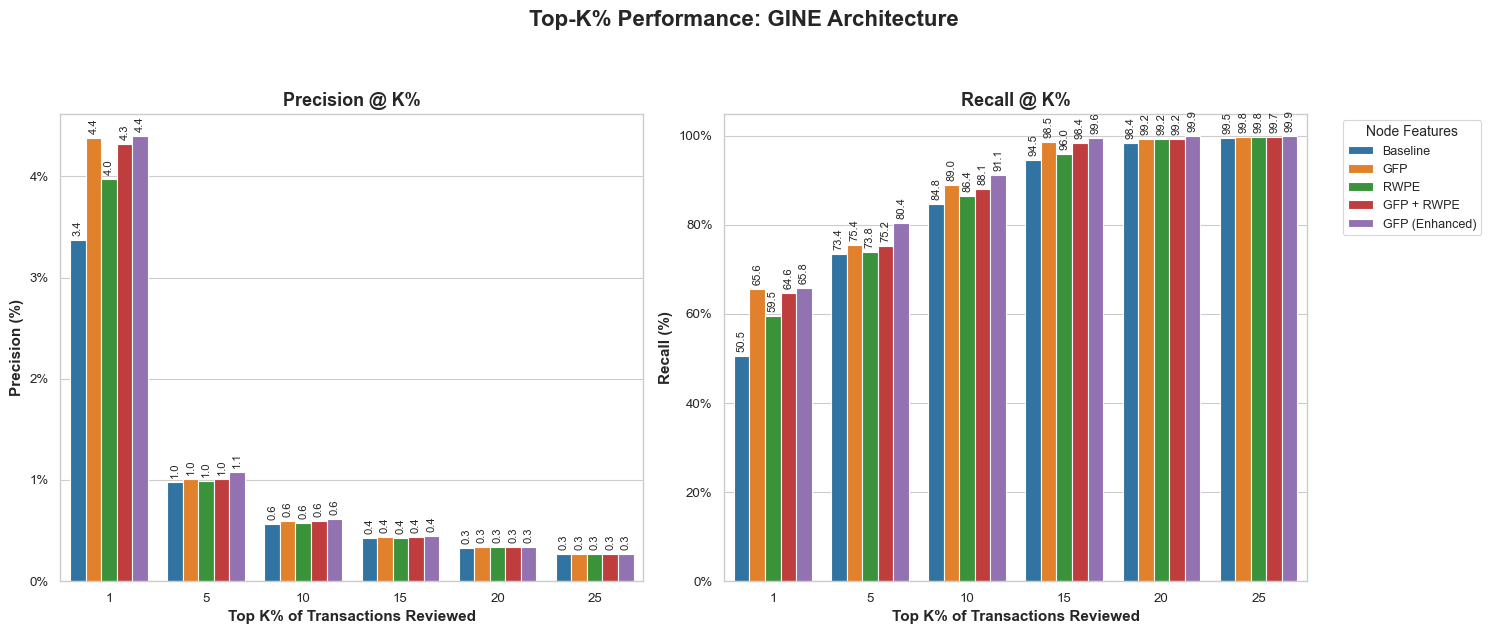

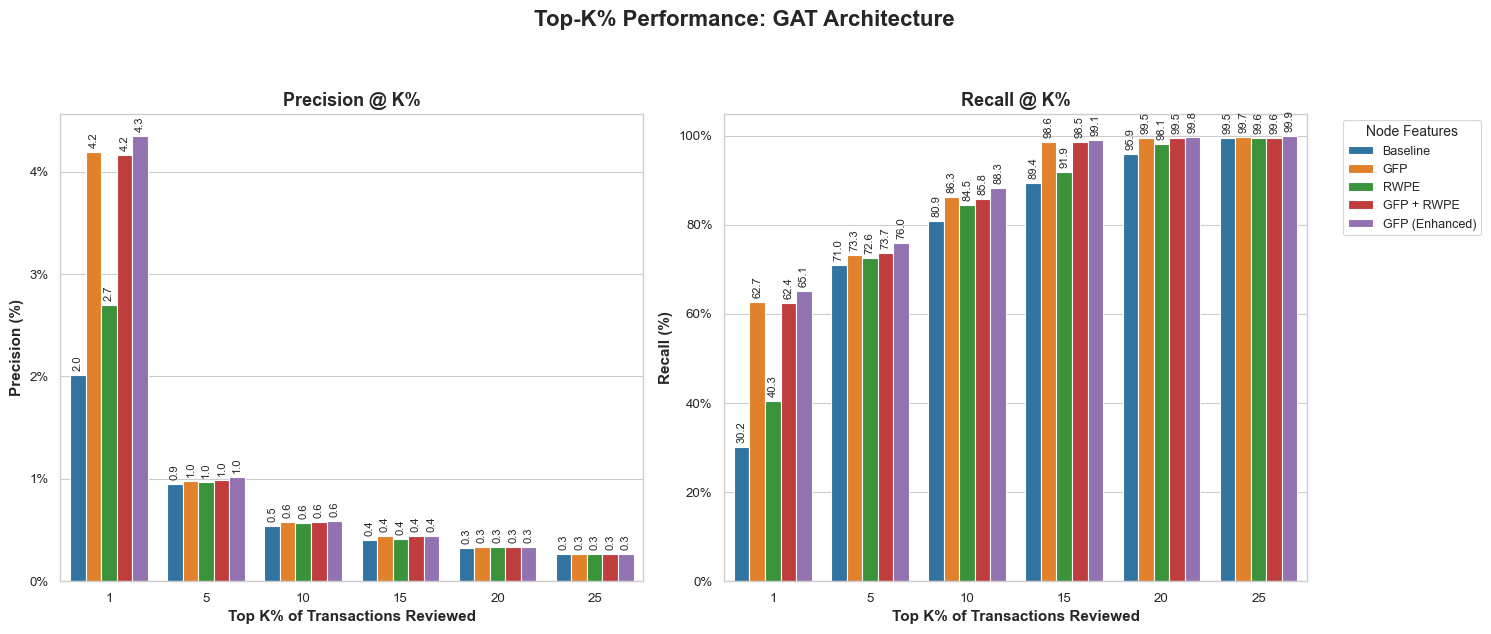

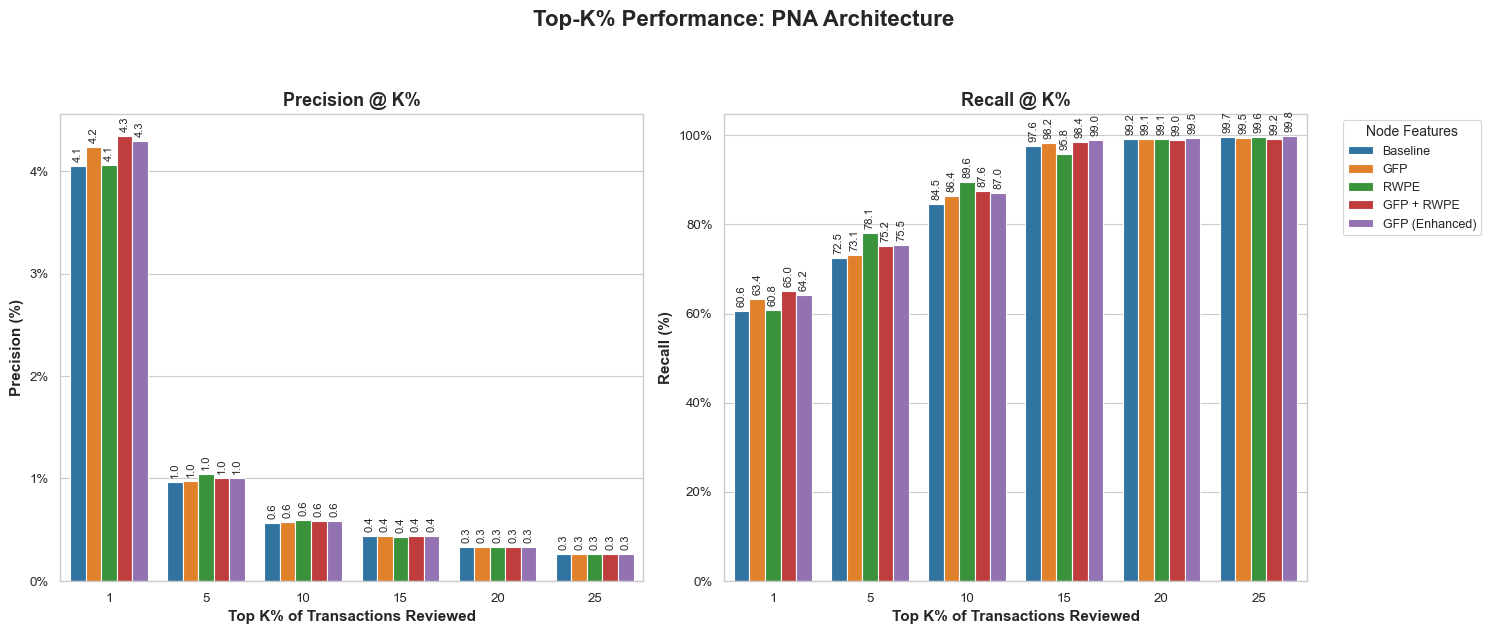

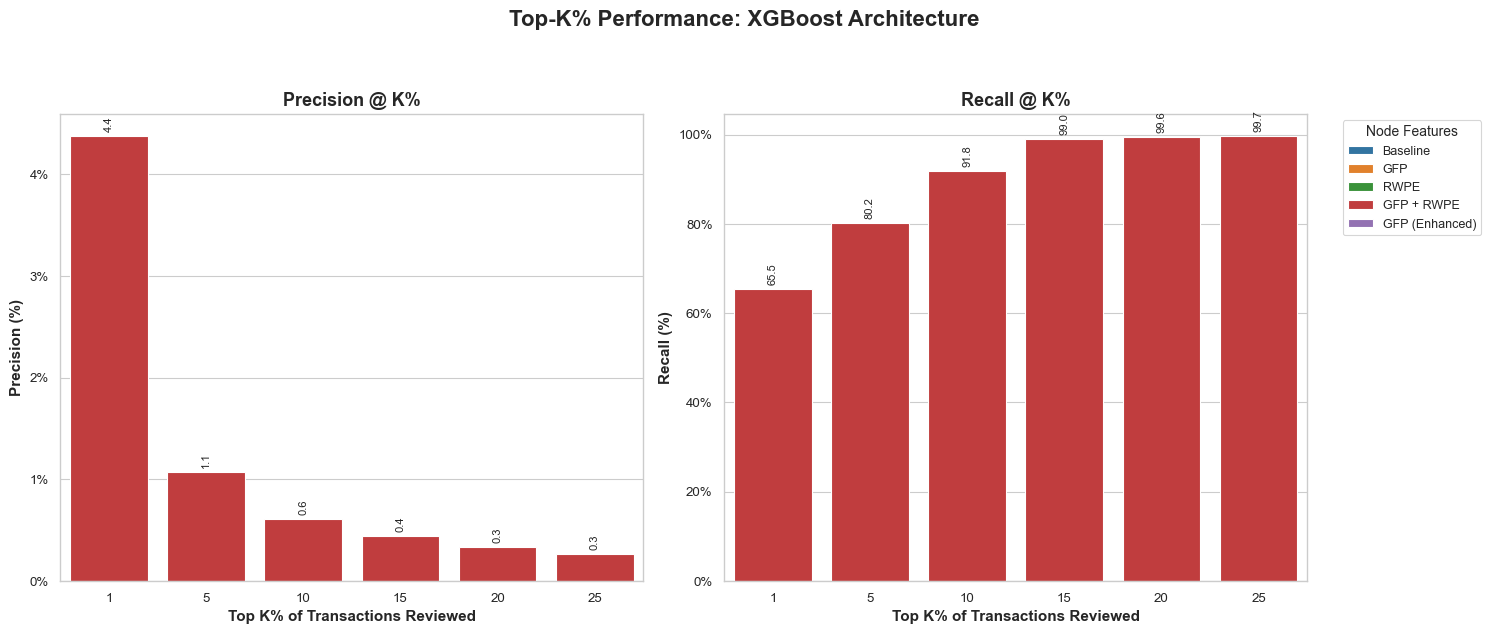

In [83]:
# To run it, filter your dataframe to the test set and pass it in:
test_set_df = df[df['split'] == 'test']
metrics_df = evaluate_top_k_all_models(test_set_df)

# Model Predictive Power on different laundering structures

In [84]:
# ── Step 1: Load raw CSV with row index ──────────────────────────────────────
col_names = [
    'Timestamp', 'From Bank', 'src_account',
    'To Bank',   'dst_account',
    'Amount Received', 'Receiving Currency',
    'Amount Paid', 'Payment Currency',
    'Payment Format', 'label'
]

df_raw = pd.read_csv(
    'Data/LI-Small_Trans.csv',
    names=col_names,
    header=0,
    low_memory=False
)
df_raw['Timestamp'] = pd.to_datetime(df_raw['Timestamp'])

print(f"Raw CSV: {len(df_raw):,} rows")
print(df_raw[['Timestamp', 'src_account', 'dst_account', 'label']].head(3))

# ── Step 2: Add src_idx / dst_idx to raw CSV using account_to_idx ────────────
with open('Data/account_to_idx.pkl', 'rb') as f:
    account_to_idx = pickle.load(f)

df_raw['src_idx'] = df_raw['src_account'].map(account_to_idx)
df_raw['dst_idx'] = df_raw['dst_account'].map(account_to_idx)
df_raw['timestamp_unix'] = df_raw['Timestamp'].astype(np.int64) // 10**9

print(f"\nUnmapped src accounts: {df_raw['src_idx'].isna().sum():,}")
print(f"Unmapped dst accounts: {df_raw['dst_idx'].isna().sum():,}")

Raw CSV: 6,924,049 rows
            Timestamp src_account dst_account  label
0 2022-09-01 00:08:00   8000ECA90   8000ECA90      0
1 2022-09-01 00:21:00   80021DAD0   80021DAD0      0
2 2022-09-01 00:00:00   8000ECA90   8006AA910      0

Unmapped src accounts: 0
Unmapped dst accounts: 0


In [85]:
# Also need amount in patterns parser — add it
def parse_patterns_file_raw(filepath):
    records      = []
    attempt_id   = 0
    pattern_type = None

    begin_re = re.compile(r'BEGIN LAUNDERING ATTEMPT\s*-\s*([\w-]+)', re.IGNORECASE)
    end_re   = re.compile(r'END LAUNDERING ATTEMPT',                   re.IGNORECASE)

    with open(filepath, 'r') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            m = begin_re.search(line)
            if m:
                attempt_id  += 1
                pattern_type = m.group(1).upper()
                continue
            if end_re.search(line):
                pattern_type = None
                continue
            if pattern_type is None:
                continue
            parts = [p.strip() for p in line.split(',')]
            if len(parts) < 11:
                continue
            try:
                records.append({
                    'Timestamp'     : pd.to_datetime(parts[0], format='%Y/%m/%d %H:%M'),
                    'src_bank'      : str(parts[1]).lstrip('0'),
                    'src_account'   : parts[2],
                    'dst_bank'      : str(parts[3]).lstrip('0'),
                    'dst_account'   : parts[4],
                    'Amount Received': float(parts[5]),
                    'Payment Format': parts[9],
                    'pattern_type'  : pattern_type,
                    'attempt_id'    : attempt_id,
                    'label'         : 1,
                })
            except (ValueError, IndexError):
                continue

    df_pat = pd.DataFrame(records)
    print(f"Parsed {len(df_pat):,} transactions across {attempt_id:,} attempts")
    return df_pat


df_patterns_raw = parse_patterns_file_raw('Data/LI-Small_Patterns.txt')

Parsed 1,023 transactions across 117 attempts


In [86]:
df_raw['From Bank'] = df_raw['From Bank'].astype(str).str.lstrip('0')
df_raw['To Bank']   = df_raw['To Bank'].astype(str).str.lstrip('0')
df_patterns_raw['src_bank'] = df_patterns_raw['src_bank'].astype(str).str.lstrip('0')
df_patterns_raw['dst_bank'] = df_patterns_raw['dst_bank'].astype(str).str.lstrip('0')

In [87]:
df_raw_enriched = df_raw.rename(columns={'From Bank': 'src_bank', 'To Bank': 'dst_bank'}).merge(
    df_patterns_raw[['Timestamp', 'src_account', 'dst_account',
                      'src_bank',  'dst_bank',
                      'Amount Received', 'Payment Format',
                      'pattern_type', 'attempt_id', 'label']],
    on =['Timestamp', 'src_account', 'dst_account',
               'src_bank', 'dst_bank',
               'Amount Received', 'Payment Format', 'label'],
    how='left'
)

In [89]:
df_raw_enriched['category'] = 'LEGIT'
df_raw_enriched.loc[(df_raw_enriched['label']==1) & (df_raw_enriched['pattern_type'].notna()), 'category'] = 'PATTERN_LAUNDERING'
df_raw_enriched.loc[(df_raw_enriched['label']==1) & (df_raw_enriched['pattern_type'].isna()),  'category'] = 'INTEGRATION_LAUNDERING'

In [90]:
df_all_enriched = df.merge(df_raw_enriched[['src_idx', 'dst_idx', 'timestamp_unix', 'category', 'pattern_type', 'attempt_id', 'label']].rename(columns={'timestamp_unix': 'timestamp'}).drop_duplicates(),
                               on=['src_idx', 'dst_idx', 'timestamp', 'label'],
                               how='left')

# df_all_enriched_pna = df.merge(df_raw_enriched[['src_idx', 'dst_idx', 'timestamp_unix', 'category', 'pattern_type', 'attempt_id', 'label']].rename(columns={'timestamp_unix': 'timestamp'}).drop_duplicates(),
#                                        on=['src_idx', 'dst_idx', 'timestamp', 'label'],
#                                        how='left')

In [91]:
df_all_enriched.shape

(6924049, 24)

In [94]:
# Mean/median score per category
print("\nScore distribution by category GINe:")
df_all_enriched.groupby('category')['score_gine_baseline'].agg(['mean','median','std','count']).round(4)


Score distribution by category GINe:


,mean,median,std,count
category,,,,
INTEGRATION_LAUNDERING,0.2728,0.2012,0.2227,2542
LEGIT,0.0166,0.0003,0.0574,6920484
PATTERN_LAUNDERING,0.4355,0.5185,0.1970,1023


In [95]:
df_all_enriched.head()

,split,src_idx,dst_idx,timestamp,label,score_gine_baseline,score_gine_gfp,score_gine_rwpe,score_gine_gfp_rwpe,score_gine_gfp_enh,...,score_gat_gfp_enh,score_pna_baseline,score_pna_gfp,score_pna_rwpe,score_pna_gfp_rwpe,score_pna_gfp_enh,score_xgboost_gfp_rwpe,category,pattern_type,attempt_id
0,train,606674,53721,1661990400,0,0.000531,0.000020,0.000079,0.000020,0.000010,...,0.000010,0.000076,0.000005,0.000094,0.000010,0.000003,0.005137,LEGIT,NaN,NaN
1,train,255381,255381,1661990400,0,0.000174,0.000080,0.000008,0.000047,0.000015,...,0.000005,0.000008,0.000021,0.000007,0.000032,0.000019,0.003267,LEGIT,NaN,NaN
2,train,578237,72342,1661990400,0,0.000258,0.000015,0.000034,0.000011,0.000003,...,0.000002,0.000013,0.000005,0.000009,0.000004,0.000003,0.002933,LEGIT,NaN,NaN
3,train,536323,510825,1661990400,0,0.001254,0.000016,0.000107,0.000012,0.000006,...,0.000003,0.000068,0.000006,0.000025,0.000005,0.000004,0.003529,LEGIT,NaN,NaN
4,train,424220,478017,1661990400,0,0.000520,0.000021,0.000023,0.000016,0.000009,...,0.000012,0.000014,0.000009,0.000008,0.000011,0.000012,0.002992,LEGIT,NaN,NaN


In [96]:
df_all_enriched['pattern_type'].value_counts()

pattern_type
SCATTER-GATHER    182
STACK             180
GATHER-SCATTER    150
FAN-OUT           149
BIPARTITE         129
CYCLE              83
RANDOM             77
FAN-IN             73
Name: count, dtype: int64

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    average_precision_score, f1_score, matthews_corrcoef, precision_recall_curve
)


def evaluate_typology_bootstrap(df, n_bootstrap=100, laund_ratio=0.10, random_seed=42):
    """
    For each laundering typology, bootstraps a 90/10 legit/laundering sample
    and computes PR-AUC, F1, and MCC for every model variant.

    Then plots 3 grouped bar charts (PR-AUC, F1, MCC) per architecture
    (GINE, GAT, PNA, XGBoost), with the same tab10 colors as plot_gnn_aml_results.

    Parameters
    ----------
    df           : enriched DataFrame with columns:
                   category, pattern_type, label, score_*
    n_bootstrap  : number of bootstrap iterations per typology
    laund_ratio  : target laundering proportion (0.10 = 10%)
    random_seed  : base RNG seed

    Returns
    -------
    df_results   : DataFrame with mean/std per model x typology
    """

    # ── 1. Model registry ────────────────────────────────────────────────────
    SCORE_COLS = {
        'GINE Baseline':       'score_gine_baseline',
        'GINE GFP':            'score_gine_gfp',
        'GINE RWPE':           'score_gine_rwpe',
        'GINE GFP+RWPE':       'score_gine_gfp_rwpe',
        'GINE GFP (Enhanced)': 'score_gine_gfp_enh',
        'GAT Baseline':        'score_gat_baseline',
        'GAT GFP':             'score_gat_gfp',
        'GAT RWPE':            'score_gat_rwpe',
        'GAT GFP+RWPE':        'score_gat_gfp_rwpe',
        'GAT GFP (Enhanced)':  'score_gat_gfp_enh',
        'PNA Baseline':        'score_pna_baseline',
        'PNA GFP':             'score_pna_gfp',
        'PNA RWPE':            'score_pna_rwpe',
        'PNA GFP+RWPE':        'score_pna_gfp_rwpe',
        'PNA GFP (Enhanced)':  'score_pna_gfp_enh',
        'XGBoost GFP+RWPE':    'score_xgboost_gfp_rwpe',
    }

    ARCH_GROUPS = {
        'GINE':    ['GINE Baseline', 'GINE GFP', 'GINE RWPE', 'GINE GFP+RWPE', 'GINE GFP (Enhanced)'],
        'GAT':     ['GAT Baseline',  'GAT GFP',  'GAT RWPE',  'GAT GFP+RWPE',  'GAT GFP (Enhanced)'],
        'PNA':     ['PNA Baseline',  'PNA GFP',  'PNA RWPE',  'PNA GFP+RWPE',  'PNA GFP (Enhanced)'],
        'XGBoost': ['XGBoost GFP+RWPE'],
    }

    # Same tab10 palette order as plot_gnn_aml_results
    FEATURE_COLORS = {
        'Baseline':       '#1f77b4',
        'GFP':            '#ff7f0e',
        'RWPE':           '#2ca02c',
        'GFP+RWPE':       '#d62728',
        'GFP (Enhanced)': '#9467bd',
    }

    FEATURE_ORDER = ['Baseline', 'GFP', 'RWPE', 'GFP+RWPE', 'GFP (Enhanced)']

    # ── 2. Build typology groups ──────────────────────────────────────────────
    pattern_types = sorted(
        df[df['category'] == 'PATTERN_LAUNDERING']['pattern_type'].dropna().unique()
    )

    groups = {}
    for pat in pattern_types:
        groups[pat] = df[df['pattern_type'] == pat]

    if (df['category'] == 'INTEGRATION_LAUNDERING').any():
        groups['INTEGRATION'] = df[df['category'] == 'INTEGRATION_LAUNDERING']

    groups['ALL LAUNDERING'] = df[df['label'] == 1]

    legit_df = df[df['category'] == 'LEGIT']

    # ── 3. Helper: best-threshold F1 and MCC ─────────────────────────────────
    def best_f1_mcc(y_true, y_score):
        prec, rec, thresholds = precision_recall_curve(y_true, y_score)
        # F1 at each threshold
        with np.errstate(divide='ignore', invalid='ignore'):
            f1_scores = np.where(
                (prec + rec) > 0,
                2 * prec * rec / (prec + rec),
                0.0
            )
        best_thr = thresholds[np.argmax(f1_scores[:-1])]
        y_pred   = (y_score >= best_thr).astype(int)
        return f1_score(y_true, y_pred, zero_division=0), \
               matthews_corrcoef(y_true, y_pred)

    # ── 4. Bootstrap loop ────────────────────────────────────────────────────
    records = []
    rng = np.random.default_rng(random_seed)

    total = len(groups) * len(SCORE_COLS)
    done  = 0

    for typology, laund_df in groups.items():
        if len(laund_df) == 0:
            continue

        n_laund = len(laund_df)
        n_legit_needed = int(round(n_laund * (1 - laund_ratio) / laund_ratio))

        for model_name, score_col in SCORE_COLS.items():
            if score_col not in df.columns:
                done += 1
                continue

            laund_scores = laund_df[score_col].values
            legit_scores  = legit_df[score_col].values

            pr_aucs, f1s, mccs = [], [], []

            for b in range(n_bootstrap):
                seed_b = rng.integers(0, 2**31)
                local_rng = np.random.default_rng(seed_b)

                # Resample laundering with replacement
                laund_idx = local_rng.choice(n_laund, size=n_laund, replace=True)
                boot_laund = laund_scores[laund_idx]

                # Sample legit without replacement (cap at pool size)
                n_sample  = min(n_legit_needed, len(legit_scores))
                legit_idx = local_rng.choice(len(legit_scores), size=n_sample, replace=False)
                boot_legit = legit_scores[legit_idx]

                scores = np.concatenate([boot_laund, boot_legit])
                labels = np.concatenate([
                    np.ones(len(boot_laund), dtype=int),
                    np.zeros(len(boot_legit), dtype=int),
                ])

                # Skip degenerate samples
                if labels.sum() == 0 or labels.sum() == len(labels):
                    continue

                pr_aucs.append(average_precision_score(labels, scores))
                f1, mcc = best_f1_mcc(labels, scores)
                f1s.append(f1)
                mccs.append(mcc)

            if len(pr_aucs) == 0:
                done += 1
                continue

            # Extract feature label (strip arch prefix)
            arch  = model_name.split()[0]
            feature = model_name.replace(arch + ' ', '').strip()

            records.append({
                'typology':       typology,
                'model':          model_name,
                'arch':           arch,
                'feature':        feature,
                'pr_auc_mean':    np.mean(pr_aucs),
                'pr_auc_std':     np.std(pr_aucs),
                'f1_mean':        np.mean(f1s),
                'f1_std':         np.std(f1s),
                'mcc_mean':       np.mean(mccs),
                'mcc_std':        np.std(mccs),
                'n_laund':        n_laund,
                'n_bootstrap':    len(pr_aucs),
            })

            done += 1
            if done % 10 == 0:
                print(f'  Progress: {done}/{total}', end='\r')

    print(f'  Done: {done}/{total}')
    df_results = pd.DataFrame(records)

    # ── 5. Plotting ──────────────────────────────────────────────────────────
    METRICS = {
        'pr_auc': 'PR AUC',
        'f1':     'F1 Score',
        'mcc':    'MCC',
    }

    typology_order = pattern_types + (
        ['INTEGRATION'] if 'INTEGRATION' in groups else []
    ) + ['ALL LAUNDERING']

    sns.set_theme(style='whitegrid', context='paper', font_scale=1.1)

    for arch, model_list in ARCH_GROUPS.items():
        arch_df = df_results[df_results['arch'] == arch].copy()
        if arch_df.empty:
            continue

        # Keep only typologies that actually appear in results
        present_typologies = [t for t in typology_order if t in arch_df['typology'].values]
        present_features   = [f for f in FEATURE_ORDER if f in arch_df['feature'].values]
        palette            = [FEATURE_COLORS[f] for f in present_features]

        fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)
        fig.suptitle(f'{arch} — Performance by Laundering Typology '
                     f'({n_bootstrap} bootstrap iterations, {int(laund_ratio*100)}% laundering)',
                     fontsize=13, fontweight='bold', y=1.02)

        for ax, (metric_key, metric_label) in zip(axes, METRICS.items()):
            mean_col = f'{metric_key}_mean'
            std_col  = f'{metric_key}_std'

            # Pivot to wide for grouped bars
            pivot = (
                arch_df[arch_df['typology'].isin(present_typologies)]
                .pivot_table(index='typology', columns='feature',
                             values=[mean_col, std_col])
                .reindex(present_typologies)
            )

            x      = np.arange(len(present_typologies))
            n_feat = len(present_features)
            width  = 0.8 / n_feat

            for i, feat in enumerate(present_features):
                if (mean_col, feat) not in pivot.columns:
                    continue
                means = pivot[(mean_col, feat)].values
                stds  = pivot[(std_col,  feat)].values

                offset = (i - n_feat / 2 + 0.5) * width
                bars = ax.bar(
                    x + offset, means,
                    width=width * 0.9,
                    label=feat,
                    color=FEATURE_COLORS[feat],
                    yerr=stds,
                    capsize=3,
                    error_kw={'linewidth': 0.8, 'alpha': 0.7},
                    alpha=0.85,
                )

            ax.set_title(metric_label, fontweight='bold', fontsize=11)
            ax.set_xlabel('Laundering Typology', fontsize=10)
            ax.set_ylabel(metric_label, fontsize=10)
            ax.set_xticks(x)
            ax.set_xticklabels(present_typologies, rotation=35, ha='right', fontsize=8)
            ax.set_ylim(bottom=0)
            ax.grid(axis='y', alpha=0.4)

        # Single shared legend per architecture
        handles = [
            plt.Rectangle((0, 0), 1, 1, color=FEATURE_COLORS[f], alpha=0.85)
            for f in present_features
        ]
        fig.legend(
            handles, present_features,
            title='Node Features',
            loc='lower center',
            ncol=len(present_features),
            bbox_to_anchor=(0.5, -0.08),
            frameon=True,
            fontsize=10,
        )

        plt.tight_layout()
        plt.savefig(f'typology_bootstrap_{arch.lower()}.png',
                    dpi=150, bbox_inches='tight')
        plt.show()

    return df_results

  Done: 160/160/160


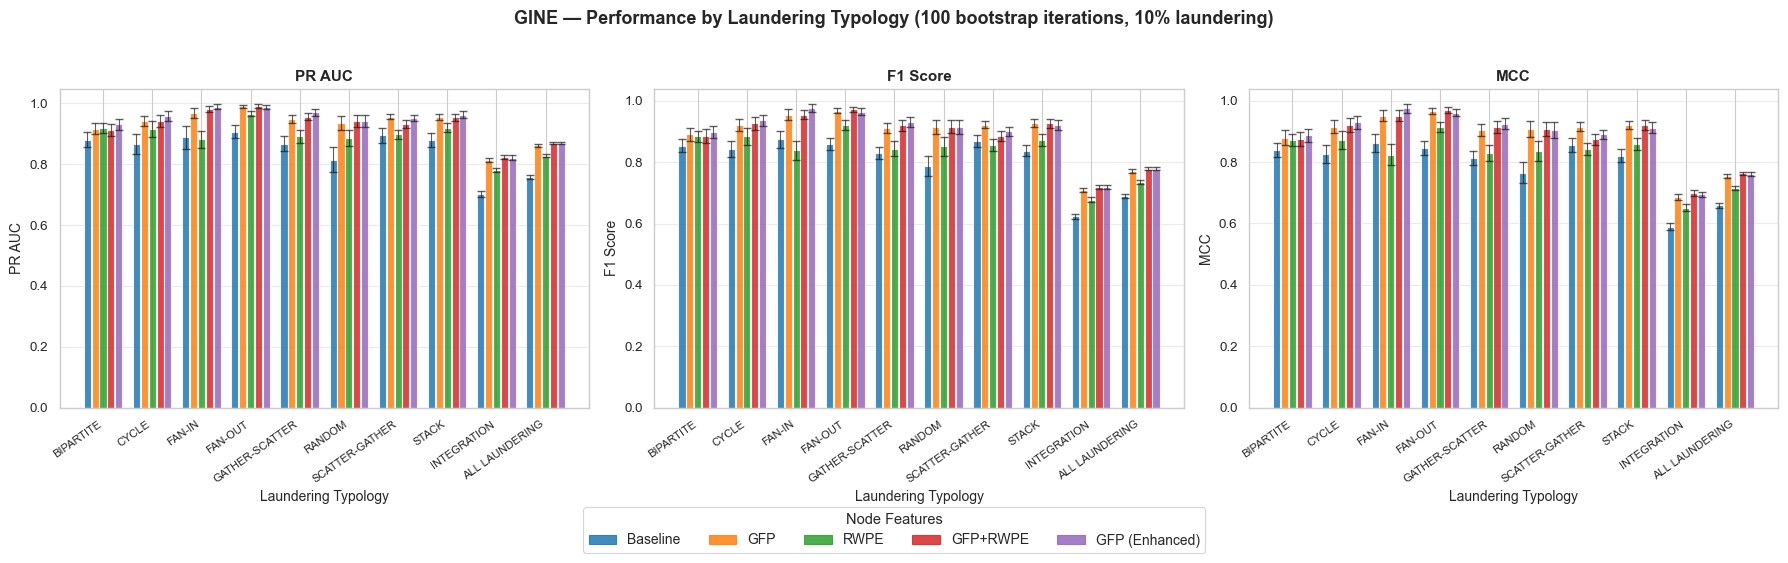

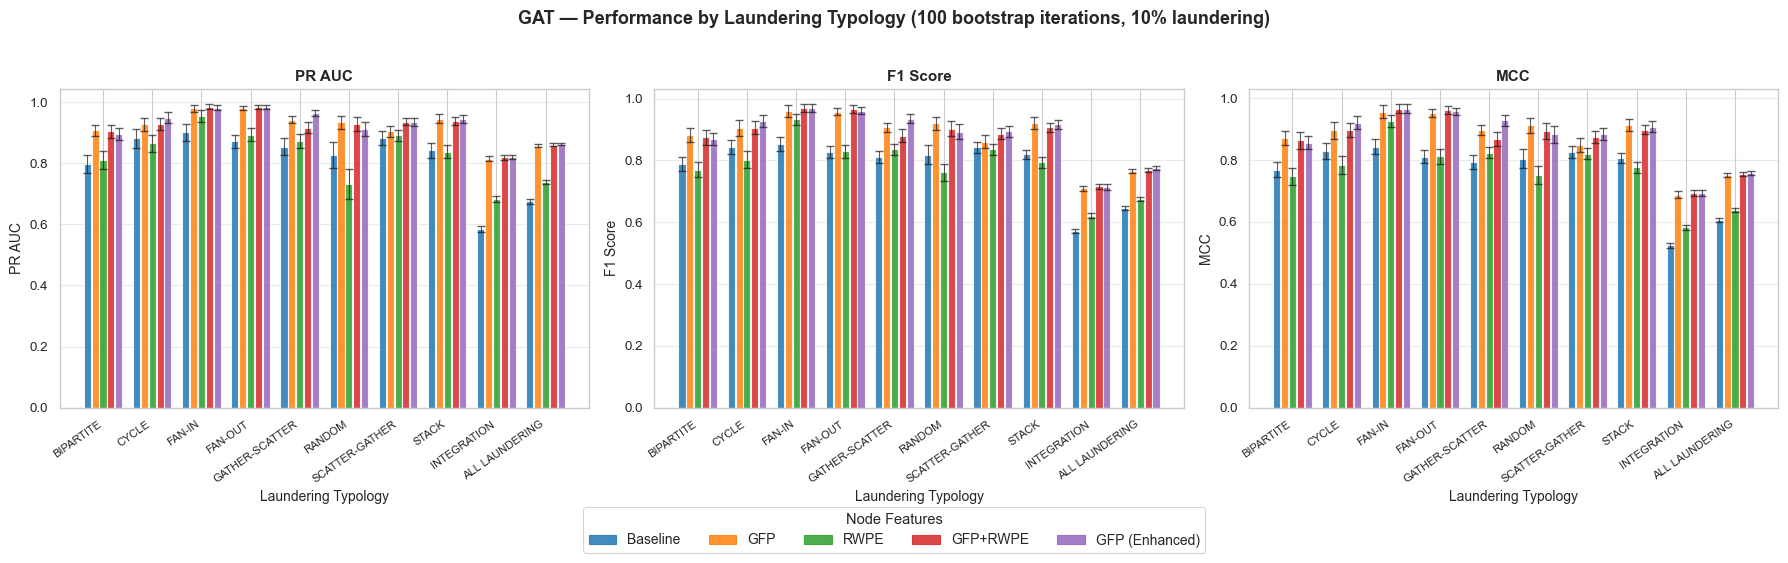

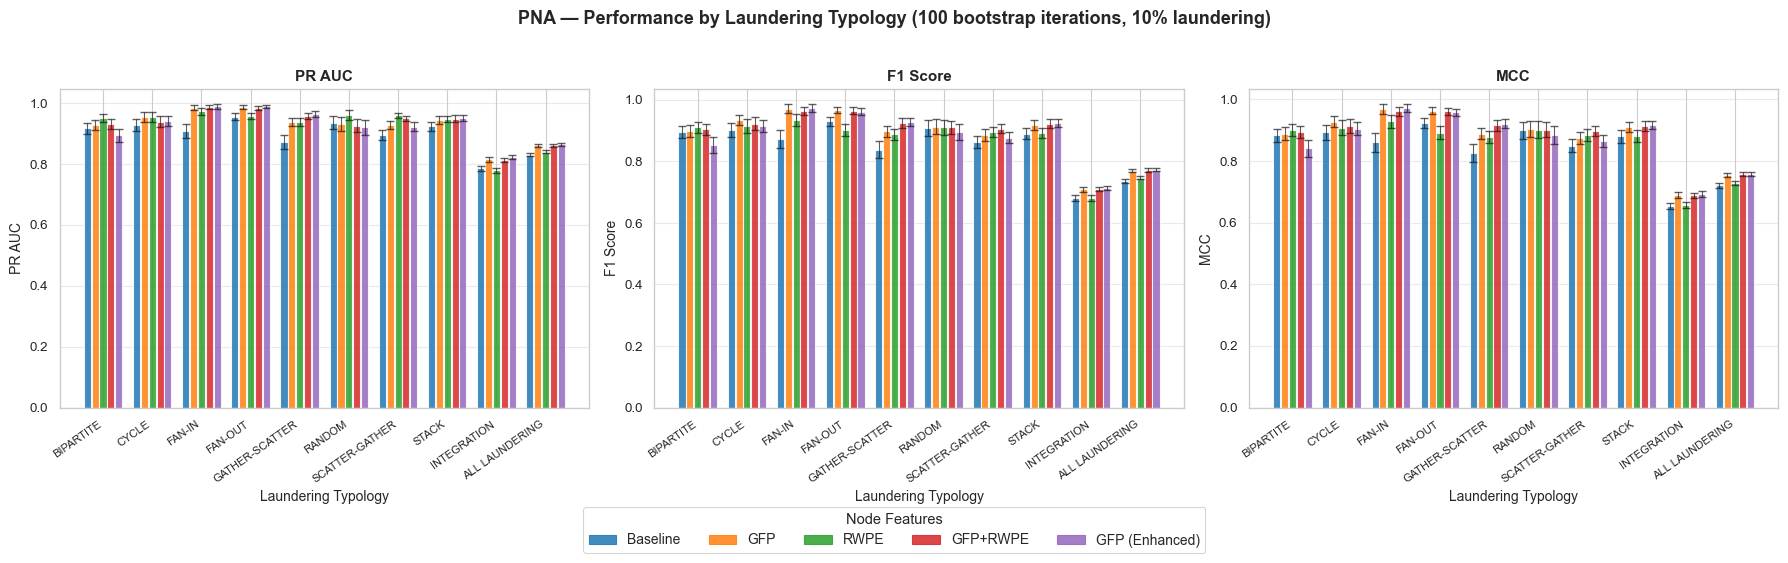

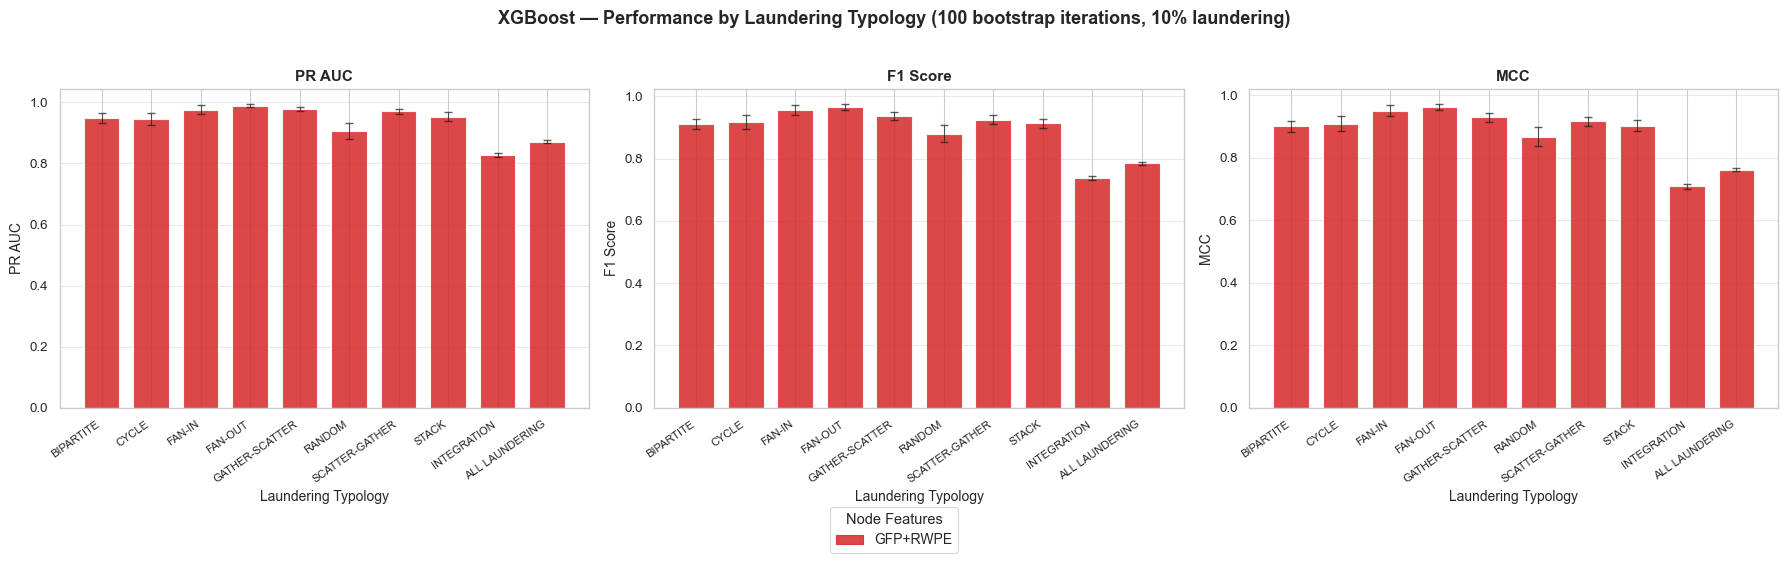

In [99]:
# ── Usage ────────────────────────────────────────────────────────────────────
# df_all is the result of merging prediction_import() with your enriched metadata
# (category, pattern_type columns must be present)

df_results = evaluate_typology_bootstrap(df_all_enriched, n_bootstrap=100)